In [11]:
!pip install -q dagshub mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import mlflow
import mlflow.sklearn
import dagshub
from kaggle_secrets import UserSecretsClient
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# MLflow setup
user_secrets = UserSecretsClient()
MLFLOW_TRACKING_PASSWORD = user_secrets.get_secret('ML_token1')
MLFLOW_TRACKING_USERNAME = user_secrets.get_secret('username')
repo_name = 'IEEE-Fraud-Detection'

mlflow.set_tracking_uri(f'https://dagshub.com/{MLFLOW_TRACKING_USERNAME}/{repo_name}.mlflow')
os.environ['MLFLOW_TRACKING_USERNAME'] = MLFLOW_TRACKING_USERNAME
os.environ['MLFLOW_TRACKING_PASSWORD'] = MLFLOW_TRACKING_PASSWORD
dagshub.init(repo_name=repo_name, repo_owner=MLFLOW_TRACKING_USERNAME, mlflow=True)
mlflow.set_experiment('RandomForest_Training')
print('✅ MLflow connected - Experiment: RandomForest_Training')

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=8acdef94-7245-42be-b0e1-5a4a60e7fe37&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=22a074b42732692ab65cd4761b680124c183feeeb95c9e505061601bd82166ee




Accessing as mgior23

Initialized MLflow to track repo "mgior23/IEEE-Fraud-Detection"

Repository mgior23/IEEE-Fraud-Detection initialized!

✅ MLflow connected - Experiment: RandomForest_Training


## Cleaning

In [12]:
# Load data
train_trans = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_id    = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')
test_trans  = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')
test_id     = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv')

# Merge transaction + identity
train = train_trans.merge(train_id, on='TransactionID', how='left')
test  = test_trans.merge(test_id,   on='TransactionID', how='left')

# Separate target
y         = train['isFraud']
train_ids = train['TransactionID']
test_ids  = test['TransactionID']

X_train = train.drop(['TransactionID', 'isFraud'], axis=1)
X_test  = test.drop(['TransactionID'], axis=1)

print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Fraud rate:  {y.mean():.2%}')

Train shape: (590540, 432)
Test shape:  (506691, 432)
Fraud rate:  3.50%


In [13]:
# Drop columns with >90% missing
missing_pct = X_train.isnull().sum() / len(X_train)
drop_cols   = missing_pct[missing_pct > 0.9].index.tolist()
print(f'Dropping {len(drop_cols)} columns with >90% missing')
X_train = X_train.drop(drop_cols, axis=1, errors='ignore')
X_test  = X_test.drop(drop_cols,  axis=1, errors='ignore')

# Drop high-cardinality categorical columns (>100 unique values)
cat_cols  = X_train.select_dtypes(include=['object']).columns
high_card = [col for col in cat_cols if X_train[col].nunique() > 100]
print(f'Dropping {len(high_card)} high-cardinality columns')
X_train = X_train.drop(high_card, axis=1, errors='ignore')
X_test  = X_test.drop(high_card,  axis=1, errors='ignore')

# Align columns
X_test = X_test.reindex(columns=X_train.columns)

print(f'Final train shape: {X_train.shape}')
print(f'Final test shape:  {X_test.shape}')

Dropping 12 columns with >90% missing
Dropping 3 high-cardinality columns
Final train shape: (590540, 417)
Final test shape:  (506691, 417)


In [14]:
# Reduce memory usage
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min  and c_max < np.iinfo(np.int8).max:  df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max: df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max: df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max: df[col] = df[col].astype(np.float32)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max: df[col] = df[col].astype(np.float32)
    return df

X_train = reduce_mem_usage(X_train)
X_test  = reduce_mem_usage(X_test)
print('✅ Memory reduced')

✅ Memory reduced


In [15]:
# Log cleaning info
with mlflow.start_run(run_name='RandomForest_Cleaning'):
    mlflow.log_params({
        'train_samples':        len(X_train),
        'test_samples':         len(X_test),
        'fraud_rate':           round(float(y.mean()), 4),
        'n_features_after_drop': X_train.shape[1],
        'dropped_missing_cols': len(drop_cols),
        'dropped_highcard_cols': len(high_card),
    })
    mlflow.log_metric('n_features', X_train.shape[1])
print('✅ Cleaning logged to MLflow')

🏃 View run RandomForest_Cleaning at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1/runs/bcfb256b6ff94baa83fe95635ba45a0a
🧪 View experiment at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1
✅ Cleaning logged to MLflow


## Feature Engineering

In [16]:
# Label-encode remaining categorical columns
cat_cols_remaining = X_train.select_dtypes(include=['object']).columns.tolist()
le_dict = {}
for col in cat_cols_remaining:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    le_dict[col] = le
print(f'Label-encoded {len(cat_cols_remaining)} columns')

Label-encoded 26 columns


In [17]:
# Transaction hour and day from TransactionDT
# TransactionDT is seconds offset from a reference time
START_DATE = pd.Timestamp('2017-12-01')
for df in [X_train, X_test]:
    df['Transaction_hour'] = (df['TransactionDT'] / 3600) % 24
    df['Transaction_day']  = (df['TransactionDT'] / (3600 * 24)) % 7
    df['Transaction_week'] = (df['TransactionDT'] / (3600 * 24 * 7)).astype(int)

# Transaction amount features
for df in [X_train, X_test]:
    df['TransactionAmt_log']   = np.log1p(df['TransactionAmt'])
    df['TransactionAmt_cents'] = df['TransactionAmt'] - df['TransactionAmt'].astype(int)

print('✅ Feature engineering done')
print(f'Shape after FE: {X_train.shape}')

✅ Feature engineering done
Shape after FE: (590540, 422)


In [18]:
# Log feature engineering info
with mlflow.start_run(run_name='RandomForest_FeatureEngineering'):
    mlflow.log_params({
        'label_encoded_cols':   len(cat_cols_remaining),
        'added_time_features':  3,
        'added_amount_features': 2,
        'total_features':       X_train.shape[1],
    })
    mlflow.log_metric('n_features_after_fe', X_train.shape[1])
print('✅ Feature Engineering logged to MLflow')

🏃 View run RandomForest_FeatureEngineering at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1/runs/7c337d6969a245a6823515c99df57070
🧪 View experiment at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1
✅ Feature Engineering logged to MLflow


## Feature Selection

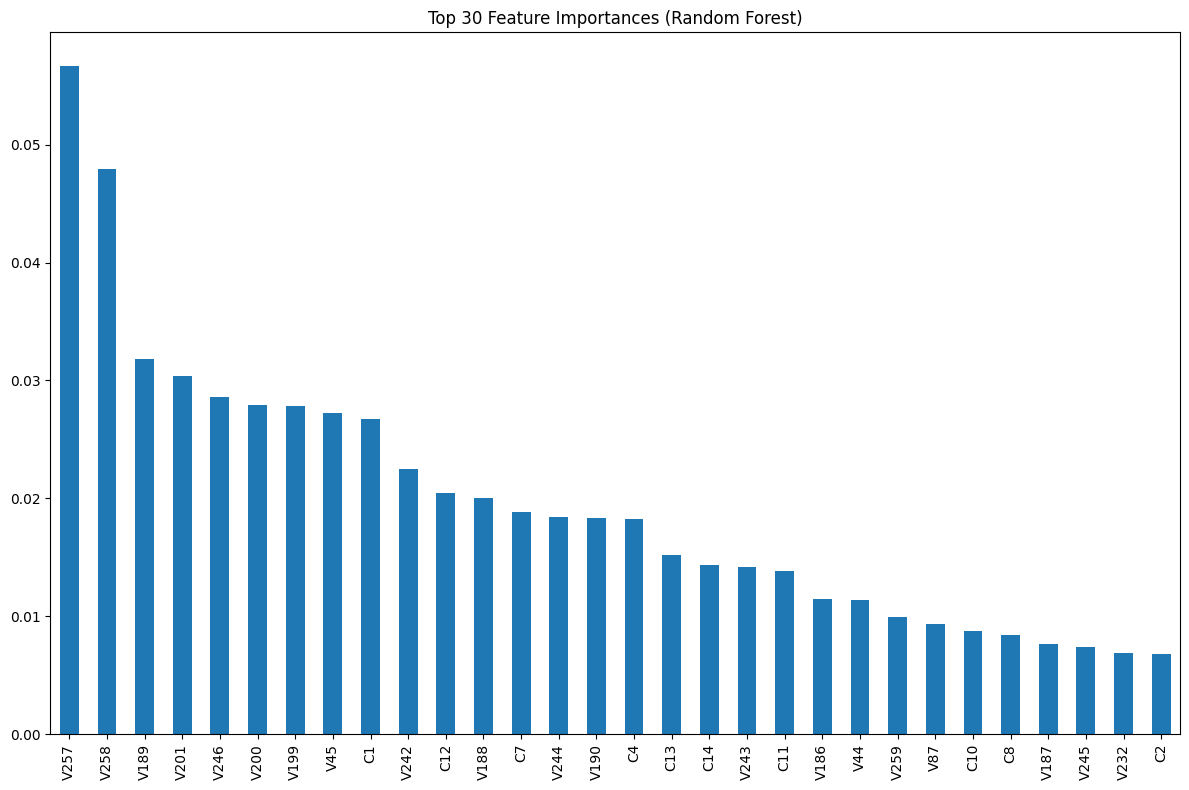

✅ Feature importances computed


In [19]:
# Fill NaN before feature selection (RF cannot handle NaN)
X_train_filled = X_train.fillna(-999)
X_test_filled  = X_test.fillna(-999)

# Quick RF to get feature importances
from sklearn.ensemble import RandomForestClassifier
selector_rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
selector_rf.fit(X_train_filled, y)

importances = pd.Series(selector_rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

# Plot top 30
plt.figure(figsize=(12, 8))
importances.head(30).plot(kind='bar')
plt.title('Top 30 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('/kaggle/working/rf_feature_importances.png')
plt.show()
print('✅ Feature importances computed')

In [20]:
# Keep top N features by importance threshold
threshold      = 0.0001
selected_cols  = importances[importances >= threshold].index.tolist()
print(f'Features above threshold {threshold}: {len(selected_cols)}')

X_train_sel = X_train_filled[selected_cols]
X_test_sel  = X_test_filled[selected_cols]
print(f'Shape after selection: {X_train_sel.shape}')

Features above threshold 0.0001: 369
Shape after selection: (590540, 369)


In [21]:
# Log feature selection to MLflow
with mlflow.start_run(run_name='RandomForest_FeatureSelection'):
    mlflow.log_params({
        'selection_method':     'RandomForest_importance',
        'importance_threshold': threshold,
        'n_features_selected':  len(selected_cols),
        'n_features_dropped':   X_train_filled.shape[1] - len(selected_cols),
    })
    mlflow.log_metric('n_selected_features', len(selected_cols))
    mlflow.log_artifact('/kaggle/working/rf_feature_importances.png')
print('✅ Feature Selection logged to MLflow')

🏃 View run RandomForest_FeatureSelection at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1/runs/12b774ec4abb4799b58a3308ef5257b4
🧪 View experiment at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1
✅ Feature Selection logged to MLflow


## Training

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [23]:
# ── v1: Baseline (shallow trees, few estimators) ─────────────────────────────
# Intentionally underfitted — shows what happens with too-simple config
params_v1 = {
    'n_estimators': 100,
    'max_depth':    5,
    'min_samples_leaf': 50,
    'random_state': 42,
    'n_jobs':       -1,
    'class_weight': 'balanced',
}
model_v1   = RandomForestClassifier(**params_v1)
cv_scores  = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_sel, y)):
    X_tr, X_val = X_train_sel.iloc[train_idx], X_train_sel.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    model_v1.fit(X_tr, y_tr)
    preds = model_v1.predict_proba(X_val)[:, 1]
    auc   = roc_auc_score(y_val, preds)
    cv_scores.append(auc)
    print(f'Fold {fold+1} AUC: {auc:.5f}')

mean_auc_v1 = np.mean(cv_scores)
std_auc_v1  = np.std(cv_scores)
print(f'\n✅ v1 Mean CV AUC: {mean_auc_v1:.5f} (+/- {std_auc_v1:.5f})')
print('   → Expected: underfitted due to shallow depth + high min_samples_leaf')

with mlflow.start_run(run_name='RandomForest_v1_underfitted'):
    mlflow.log_params(params_v1)
    mlflow.log_params({'note': 'intentionally_underfitted'})
    mlflow.log_metrics({'cv_auc_mean': mean_auc_v1, 'cv_auc_std': std_auc_v1})
    mlflow.sklearn.log_model(model_v1, 'model')

Fold 1 AUC: 0.85184
Fold 2 AUC: 0.85093
Fold 3 AUC: 0.84802
Fold 4 AUC: 0.84940
Fold 5 AUC: 0.84978

✅ v1 Mean CV AUC: 0.84999 (+/- 0.00131)
   → Expected: underfitted due to shallow depth + high min_samples_leaf


2026/05/05 07:59:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 07:59:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForest_v1_underfitted at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1/runs/708b6b29044c41919cde0353a1a36928
🧪 View experiment at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1


In [24]:
# ── v2: Overfitted (deep trees, many estimators, no regularization) ───────────
params_v2 = {
    'n_estimators': 500,
    'max_depth': None,       # unlimited depth = overfitting
    'min_samples_leaf': 1,   # very small = memorizes training data
    'random_state': 42,
    'n_jobs': -1,
    'class_weight': 'balanced',
}
model_v2 = RandomForestClassifier(**params_v2)
cv_scores_v2 = []
train_aucs_v2 = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_sel, y)):
    X_tr, X_val = X_train_sel.iloc[train_idx], X_train_sel.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    model_v2.fit(X_tr, y_tr)
    train_preds = model_v2.predict_proba(X_tr)[:, 1]
    val_preds = model_v2.predict_proba(X_val)[:, 1]
    train_aucs_v2.append(roc_auc_score(y_tr, train_preds))
    cv_scores_v2.append(roc_auc_score(y_val, val_preds))
    print(f'Fold {fold+1}  Train AUC: {train_aucs_v2[-1]:.5f}  Val AUC: {cv_scores_v2[-1]:.5f}')

mean_auc_v2 = np.mean(cv_scores_v2)
std_auc_v2 = np.std(cv_scores_v2)
mean_train_v2 = np.mean(train_aucs_v2)
print(f'\n✅ v2 Mean CV AUC: {mean_auc_v2:.5f} (+/- {std_auc_v2:.5f})')
print(f'   Mean Train AUC: {mean_train_v2:.5f}')
print(f'   → Gap = {mean_train_v2 - mean_auc_v2:.5f}')
print('   → Expected: overfitted — train AUC ~1.0, val AUC lower')

with mlflow.start_run(run_name='RandomForest_v2_overfitted'):
    mlflow.log_params(params_v2)
    mlflow.log_params({'note': 'intentionally_overfitted'})
    mlflow.log_metrics({
        'cv_auc_mean': mean_auc_v2,
        'cv_auc_std': std_auc_v2,
        'train_auc_mean': mean_train_v2,
        'overfit_gap': round(mean_train_v2 - mean_auc_v2, 5),
    })
    mlflow.sklearn.log_model(model_v2, 'model')

Fold 1  Train AUC: 1.00000  Val AUC: 0.94390
Fold 2  Train AUC: 1.00000  Val AUC: 0.94472
Fold 3  Train AUC: 1.00000  Val AUC: 0.93979
Fold 4  Train AUC: 1.00000  Val AUC: 0.94352
Fold 5  Train AUC: 1.00000  Val AUC: 0.94302

✅ v2 Mean CV AUC: 0.94299 (+/- 0.00169)
   Mean Train AUC: 1.00000
   → Gap = 0.05701
   → Expected: overfitted — train AUC ~1.0, val AUC lower


2026/05/05 08:37:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 08:37:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForest_v2_overfitted at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1/runs/be38416ab34d4a30b98b86afb46c9b46
🧪 View experiment at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1


In [25]:
# ── v3: Balanced / well-tuned ─────────────────────────────────────────────────
params_v3 = {
    'n_estimators':     300,
    'max_depth':        15,
    'min_samples_leaf': 10,
    'max_features':     'sqrt',
    'random_state':     42,
    'n_jobs':           -1,
    'class_weight':     'balanced',
}
model_v3    = RandomForestClassifier(**params_v3)
cv_scores_v3 = []
train_aucs_v3 = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_sel, y)):
    X_tr, X_val = X_train_sel.iloc[train_idx], X_train_sel.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    model_v3.fit(X_tr, y_tr)
    train_preds = model_v3.predict_proba(X_tr)[:, 1]
    val_preds   = model_v3.predict_proba(X_val)[:, 1]
    train_aucs_v3.append(roc_auc_score(y_tr, train_preds))
    cv_scores_v3.append(roc_auc_score(y_val, val_preds))
    print(f'Fold {fold+1}  Train AUC: {train_aucs_v3[-1]:.5f}  Val AUC: {cv_scores_v3[-1]:.5f}')

mean_auc_v3  = np.mean(cv_scores_v3)
std_auc_v3   = np.std(cv_scores_v3)
mean_train_v3 = np.mean(train_aucs_v3)
print(f'\n✅ v3 Mean CV AUC: {mean_auc_v3:.5f} (+/- {std_auc_v3:.5f})')
print(f'   Mean Train AUC: {mean_train_v3:.5f}')
print(f'   → Gap = {mean_train_v3 - mean_auc_v3:.5f}')

with mlflow.start_run(run_name='RandomForest_v3_balanced'):
    mlflow.log_params(params_v3)
    mlflow.log_params({'note': 'balanced_depth_regularisation'})
    mlflow.log_metrics({
        'cv_auc_mean':    mean_auc_v3,
        'cv_auc_std':     std_auc_v3,
        'train_auc_mean': mean_train_v3,
        'overfit_gap':    round(mean_train_v3 - mean_auc_v3, 5),
    })
    mlflow.sklearn.log_model(model_v3, 'model')

Fold 1  Train AUC: 0.94799  Val AUC: 0.91407
Fold 2  Train AUC: 0.94942  Val AUC: 0.91609
Fold 3  Train AUC: 0.94951  Val AUC: 0.91344
Fold 4  Train AUC: 0.94972  Val AUC: 0.91364
Fold 5  Train AUC: 0.94892  Val AUC: 0.91457

✅ v3 Mean CV AUC: 0.91436 (+/- 0.00095)
   Mean Train AUC: 0.94911
   → Gap = 0.03475


2026/05/05 08:54:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 08:54:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForest_v3_balanced at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1/runs/f6eeeb18b36e43b8a5cc32cd73fc492e
🧪 View experiment at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1


In [26]:
# ── v4: More estimators + stricter regularisation ─────────────────────────────
params_v4 = {
    'n_estimators':       500,
    'max_depth':          12,
    'min_samples_leaf':   20,
    'min_samples_split':  10,
    'max_features':       0.5,
    'max_samples':        0.8,
    'random_state':       42,
    'n_jobs':             -1,
    'class_weight':       'balanced_subsample',
}
model_v4    = RandomForestClassifier(**params_v4)
cv_scores_v4 = []
train_aucs_v4 = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_sel, y)):
    X_tr, X_val = X_train_sel.iloc[train_idx], X_train_sel.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    model_v4.fit(X_tr, y_tr)
    train_preds = model_v4.predict_proba(X_tr)[:, 1]
    val_preds   = model_v4.predict_proba(X_val)[:, 1]
    train_aucs_v4.append(roc_auc_score(y_tr, train_preds))
    cv_scores_v4.append(roc_auc_score(y_val, val_preds))
    print(f'Fold {fold+1}  Train AUC: {train_aucs_v4[-1]:.5f}  Val AUC: {cv_scores_v4[-1]:.5f}')

mean_auc_v4  = np.mean(cv_scores_v4)
std_auc_v4   = np.std(cv_scores_v4)
mean_train_v4 = np.mean(train_aucs_v4)
print(f'\n✅ v4 Mean CV AUC: {mean_auc_v4:.5f} (+/- {std_auc_v4:.5f})')
print(f'   Mean Train AUC: {mean_train_v4:.5f}')
print(f'   → Gap = {mean_train_v4 - mean_auc_v4:.5f}')

with mlflow.start_run(run_name='RandomForest_v4_strict_reg'):
    mlflow.log_params(params_v4)
    mlflow.log_params({'note': 'strict_regularisation_max_samples'})
    mlflow.log_metrics({
        'cv_auc_mean':    mean_auc_v4,
        'cv_auc_std':     std_auc_v4,
        'train_auc_mean': mean_train_v4,
        'overfit_gap':    round(mean_train_v4 - mean_auc_v4, 5),
    })
    mlflow.sklearn.log_model(model_v4, 'model')

Fold 1  Train AUC: 0.93666  Val AUC: 0.91470
Fold 2  Train AUC: 0.93578  Val AUC: 0.91367
Fold 3  Train AUC: 0.93793  Val AUC: 0.91155
Fold 4  Train AUC: 0.93804  Val AUC: 0.91187
Fold 5  Train AUC: 0.93722  Val AUC: 0.91179

✅ v4 Mean CV AUC: 0.91272 (+/- 0.00125)
   Mean Train AUC: 0.93713
   → Gap = 0.02441


2026/05/05 11:27:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 11:27:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForest_v4_strict_reg at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1/runs/f868c7909fa140c9828e5f6617797911
🧪 View experiment at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1


       Version  Val_AUC      Std
v1_underfitted 0.849993 0.001311
 v2_overfitted 0.942990 0.001694
   v3_balanced 0.914360 0.000948
 v4_strict_reg 0.912718 0.001249


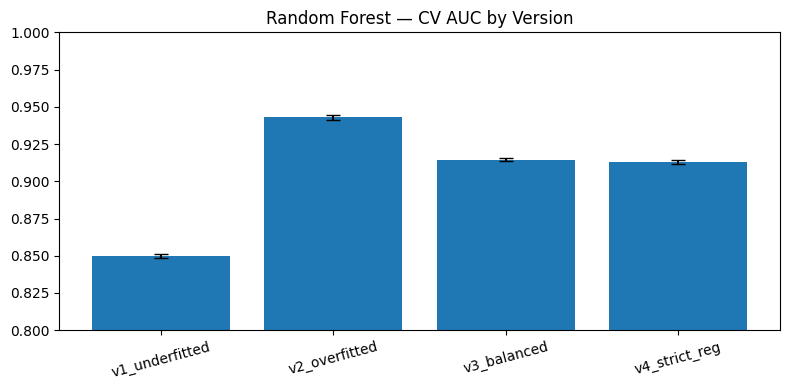


🏆 Best version: v2_overfitted  AUC: 0.94299


In [27]:
# ── Compare all versions ──────────────────────────────────────────────────────
results = pd.DataFrame({
    'Version':  ['v1_underfitted', 'v2_overfitted', 'v3_balanced', 'v4_strict_reg'],
    'Val_AUC':  [mean_auc_v1, mean_auc_v2, mean_auc_v3, mean_auc_v4],
    'Std':      [std_auc_v1,  std_auc_v2,  std_auc_v3,  std_auc_v4],
})
print(results.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.bar(results['Version'], results['Val_AUC'], yerr=results['Std'], capsize=5)
plt.ylim(0.8, 1.0)
plt.title('Random Forest — CV AUC by Version')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('/kaggle/working/rf_version_comparison.png')
plt.show()

best_auc  = max(mean_auc_v1, mean_auc_v2, mean_auc_v3, mean_auc_v4)
best_idx  = np.argmax([mean_auc_v1, mean_auc_v2, mean_auc_v3, mean_auc_v4])
best_params = [params_v1, params_v2, params_v3, params_v4][best_idx]
best_name   = ['v1_underfitted', 'v2_overfitted', 'v3_balanced', 'v4_strict_reg'][best_idx]
print(f'\n🏆 Best version: {best_name}  AUC: {best_auc:.5f}')

In [28]:
# Define best model (v3 - better generalization than overfitted v2)
best_params = params_v3
best_name = 'v3_balanced'
best_auc = mean_auc_v3

# X_train_sel should already exist from feature selection cell above
# If not, recreate it:
X_train_sel = X_train[selected_cols]

print(f'🏆 Best: {best_name}  AUC: {best_auc:.5f}')
print(f'X_train_sel shape: {X_train_sel.shape}')

🏆 Best: v3_balanced  AUC: 0.91436
X_train_sel shape: (590540, 369)


In [29]:
# ── Train final model on full data & register ─────────────────────────────────
final_model = RandomForestClassifier(**best_params)
final_model.fit(X_train_sel, y)

# Save preprocessing info
preprocessing_info = {
    'drop_cols':      drop_cols,
    'high_card':      high_card,
    'le_dict':        le_dict,
    'selected_cols':  selected_cols,
    'feature_cols':   X_train_sel.columns.tolist(),
}
with open('/kaggle/working/rf_preprocessing.pkl', 'wb') as f:
    pickle.dump(preprocessing_info, f)

with mlflow.start_run(run_name='RandomForest_Final_Model') as run:
    mlflow.log_params(best_params)
    mlflow.log_params({'best_version': best_name})
    mlflow.log_metrics({
        'final_cv_auc_mean': best_auc,
    })
    mlflow.log_artifact('/kaggle/working/rf_preprocessing.pkl')
    mlflow.log_artifact('/kaggle/working/rf_version_comparison.png')
    mlflow.sklearn.log_model(
        final_model,
        artifact_path='rf_final_pipeline',
        registered_model_name='RandomForest_FraudDetection',
    )
    run_id = run.info.run_id
    print(f'✅ Run ID: {run_id}')

print(f'✅ Best version: {best_name}')
print(f'✅ Best CV AUC:  {best_auc:.5f}')
print("✅ Model registered as 'RandomForest_FraudDetection'")

2026/05/05 11:35:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 11:35:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'RandomForest_FraudDetection'.
2026/05/05 11:35:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RandomForest_FraudDetection, version 1
Created version '1' of model 'RandomForest_FraudDetection'.


✅ Run ID: d0c5005e202e4f6699c98b850736d557
🏃 View run RandomForest_Final_Model at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1/runs/d0c5005e202e4f6699c98b850736d557
🧪 View experiment at: https://dagshub.com/mgior23/IEEE-Fraud-Detection.mlflow/#/experiments/1
✅ Best version: v3_balanced
✅ Best CV AUC:  0.91436
✅ Model registered as 'RandomForest_FraudDetection'
